🔄 กำลังเชื่อมต่อ Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ เครื่องนี้ประมวลผลด้วย: cuda
✅ พบรูปภาพทั้งหมด: 309 รูป
✅ พบ Class ทั้งหมด 5 ประเภท: ['class 0', 'class 1', 'class 2', 'class 3', 'class 4']

🧠 กำลังโหลดโมเดล ShuffleNet V2...

🚀 เริ่มเทรนโมเดลจำนวน 50 รอบ (Epochs)...


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ShuffleNet_V2_X1_0_Weights.IMAGENET1K_V1`. You can also use `weights=ShuffleNet_V2_X1_0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


   Epoch 1/50 -> Loss: 1.6138 | Accuracy: 0.1943
   Epoch 2/50 -> Loss: 1.6127 | Accuracy: 0.1943
   Epoch 3/50 -> Loss: 1.6112 | Accuracy: 0.1943
   Epoch 4/50 -> Loss: 1.6090 | Accuracy: 0.1943
   Epoch 5/50 -> Loss: 1.6072 | Accuracy: 0.1943
   Epoch 6/50 -> Loss: 1.6055 | Accuracy: 0.1943
   Epoch 7/50 -> Loss: 1.6037 | Accuracy: 0.2186
   Epoch 8/50 -> Loss: 1.6020 | Accuracy: 0.2267
   Epoch 9/50 -> Loss: 1.5998 | Accuracy: 0.2551
   Epoch 10/50 -> Loss: 1.5984 | Accuracy: 0.2794
   Epoch 11/50 -> Loss: 1.5967 | Accuracy: 0.3158
   Epoch 12/50 -> Loss: 1.5950 | Accuracy: 0.3482
   Epoch 13/50 -> Loss: 1.5933 | Accuracy: 0.3401
   Epoch 14/50 -> Loss: 1.5922 | Accuracy: 0.3725
   Epoch 15/50 -> Loss: 1.5905 | Accuracy: 0.3806
   Epoch 16/50 -> Loss: 1.5892 | Accuracy: 0.3644
   Epoch 17/50 -> Loss: 1.5876 | Accuracy: 0.3725
   Epoch 18/50 -> Loss: 1.5865 | Accuracy: 0.3684
   Epoch 19/50 -> Loss: 1.5849 | Accuracy: 0.3927
   Epoch 20/50 -> Loss: 1.5838 | Accuracy: 0.3644
   Epoch 

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3588 (\N{THAI CHARACTER KHO KHWAI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3623 (\N{THAI CHARACTER WO WAEN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3634 (\N{THAI CHARACTER SARA AA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3617 (\N{THAI CHARACTER MO MA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3592 (\N{THAI CHARACTER CHO CHAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, 

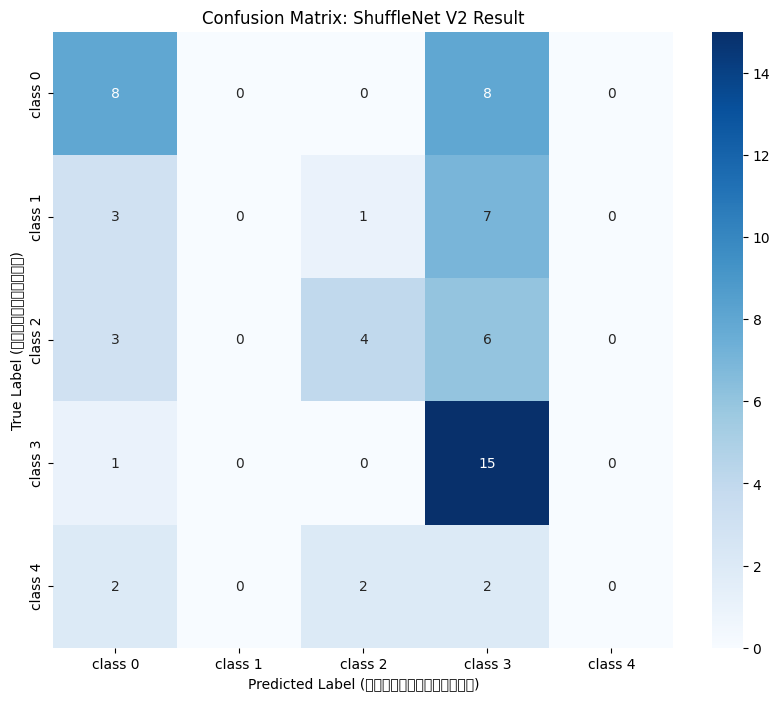

In [5]:
# ==========================================
# ส่วนที่ 1: เตรียมเครื่องมือและเชื่อมต่อ Drive
# ==========================================
from google.colab import drive
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np
import os

# เชื่อมต่อ Google Drive
print("🔄 กำลังเชื่อมต่อ Google Drive...")
drive.mount('/content/drive')

# ตรวจสอบ GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ เครื่องนี้ประมวลผลด้วย: {device}")

# ==========================================
# ส่วนที่ 2: เตรียมข้อมูล (Data Processing)
# ==========================================
# การแปลงรูปภาพให้เหมาะกับ ShuffleNet (ขนาด 224x224)
data_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.CenterCrop(224), # ตัดส่วนกลางภาพ
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# ระบุตำแหน่งโฟลเดอร์ (ตามชื่อทางลัดที่เราสร้าง)
data_dir = '/content/drive/MyDrive/Coffee_Project'

# เช็คว่าเจอโฟลเดอร์ไหม
if not os.path.exists(data_dir):
    print(f"❌ Error: ไม่พบโฟลเดอร์ '{data_dir}'")
    print("⚠️ คำเตือน: คุณอาจยังไม่ได้สร้าง 'ทางลัด' หรือตั้งชื่อไม่ตรงคำว่า Coffee_Project ใน My Drive ครับ")
else:
    # โหลดข้อมูล
    full_dataset = datasets.ImageFolder(root=data_dir, transform=data_transforms)
    class_names = full_dataset.classes
    print(f"✅ พบรูปภาพทั้งหมด: {len(full_dataset)} รูป")
    print(f"✅ พบ Class ทั้งหมด {len(class_names)} ประเภท: {class_names}")

    # แบ่งข้อมูล: 80% สอน (Train), 20% สอบ (Validation)
    train_size = int(0.8 * len(full_dataset))
    val_size = len(full_dataset) - train_size
    train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

    # สร้างตัวลำเลียงข้อมูล (DataLoader)
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

    # ==========================================
    # ส่วนที่ 3: สร้างสมองและเริ่มเทรน (Training)
    # ==========================================
    print("\n🧠 กำลังโหลดโมเดล ShuffleNet V2...")
    model = models.shufflenet_v2_x1_0(pretrained=True)

    # แก้ไขเลเยอร์สุดท้ายให้เหลือแค่ 5 Class (ตามจำนวนประเภทกาแฟ)
    num_ftrs = model.fc.in_features
    model.fc = nn.Linear(num_ftrs, len(class_names))

    model = model.to(device) # ย้ายเข้า GPU

    # ตั้งค่าการสอน
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)

    # เริ่มวนรอบสอน (2 Epochs)
    num_epochs = 50
    print(f"\n🚀 เริ่มเทรนโมเดลจำนวน {num_epochs} รอบ (Epochs)...")

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        running_corrects = 0

        # วนลูปสอนทีละ Batch
        for inputs, labels in train_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        epoch_loss = running_loss / len(train_dataset)
        epoch_acc = running_corrects.double() / len(train_dataset)
        print(f'   Epoch {epoch+1}/{num_epochs} -> Loss: {epoch_loss:.4f} | Accuracy: {epoch_acc:.4f}')

    print("🎉 เทรนเสร็จเรียบร้อย!")

    # ==========================================
    # ส่วนที่ 4: ประเมินผลและสร้างกราฟ (Evaluation)
    # ==========================================
    print("\n📊 กำลังทำนายผลและสร้าง Confusion Matrix...")
    y_pred = []
    y_true = []

    model.eval() # เปลี่ยนเป็นโหมดทดสอบ
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            y_pred.extend(preds.view(-1).cpu().numpy())
            y_true.extend(labels.view(-1).cpu().numpy())

    # สร้างกราฟ Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted Label (โมเดลทำนายว่า)')
    plt.ylabel('True Label (ความจริงคือ)')
    plt.title('Confusion Matrix: ShuffleNet V2 Result')
    plt.show()